# Assignment 1 – Part 2: Power-ups 🚀

**Checklista:**
- [x] MLOps: checkpoints, versionshantering, träningsövervakning
- [x] Data augmentation
- [x] CNN (Convolutional Neural Network)
- [x] Flera CNN-arkitekturer
- [x] Regularisering (Dropout, BatchNorm, Weight decay)
- [x] 🚀 Hyper-parameter tuning (överkurs)
- [x] 🚀 MLOps-verktyg (TensorBoard)


## 0. Imports & setup

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os
import json
import time
from datetime import datetime
import pandas as pd
import matplotlib.gridspec as gridspec
from torch.utils.tensorboard import SummaryWriter

# Reproducerbarhet
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Använder: {DEVICE}")

Använder: cuda


In [4]:
if torch.cuda.is_available():
    print("PyTorch version:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
    print("CUDA version (compiled):", torch.version.cuda)
    print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

    x = torch.randn(3,3).cuda()
    print(x @ x) 

PyTorch version: 2.11.0+cu128
CUDA available: True
CUDA version (compiled): 12.8
GPU name: NVIDIA GeForce RTX 3090
tensor([[ 0.6608, -0.2509,  0.1632],
        [-0.5925,  1.4094,  0.1772],
        [ 1.6160,  0.7063,  0.8497]], device='cuda:0')


---
## 1. MLOps – Versionshantering & Checkpoints

In [5]:
def create_run_dir(run_name: str, base_dir: str = "runs") -> str:
    """Skapar en mapp för varje träningskörning med timestamp."""
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    run_dir = os.path.join(base_dir, f"{timestamp}_{run_name}")
    os.makedirs(run_dir, exist_ok=True)
    os.makedirs(os.path.join(run_dir, "checkpoints"), exist_ok=True)
    print(f"Run-mapp skapad: {run_dir}")
    return run_dir


def save_checkpoint(model, optimizer, epoch, val_loss, run_dir, is_best=False):
    """Sparar en checkpoint. Markerar den bästa med 'best'."""
    ckpt_dir = os.path.join(run_dir, "checkpoints")
    filename = f"epoch_{epoch:03d}_val{val_loss:.4f}.pt"
    filepath = os.path.join(ckpt_dir, filename)
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "val_loss": val_loss,
    }, filepath)
    if is_best:
        best_path = os.path.join(ckpt_dir, "best_model.pt")
        torch.save(torch.load(filepath), best_path)
        print(f"  💾 Ny bästa checkpoint sparad: epoch {epoch}, val_loss={val_loss:.4f}")
    return filepath


def save_run_config(config: dict, run_dir: str):
    """Sparar alla hyperparametrar som JSON så att körningen kan reproduceras."""
    config_path = os.path.join(run_dir, "config.json")
    with open(config_path, "w") as f:
        json.dump(config, f, indent=2)
    print(f"Config sparad: {config_path}")


def load_checkpoint(model, optimizer, checkpoint_path):
    """Laddar en sparad checkpoint."""
    ckpt = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    print(f"Laddade checkpoint från epoch {ckpt['epoch']}, val_loss={ckpt['val_loss']:.4f}")
    return ckpt["epoch"], ckpt["val_loss"]

---
## 2. Data augmentation


In [6]:
# Ange dataset – byt till ditt eget om det inte är MNIST!
DATASET = "MNIST"  # Alternativ: "FashionMNIST", "CIFAR10"

# --- Transforms ---
# OBS: Anpassa mean/std till ditt dataset (dessa är för MNIST)
MEAN = (0.1307,)
STD  = (0.3081,)

train_transform = transforms.Compose([
    transforms.RandomRotation(degrees=15),          # Slumpmässig rotation ±10°
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # Liten förflyttning
    #transforms.ColorJitter(brightness=0.0, contrast=0.0),      # Ljusstyrka/kontrast
    # transforms.RandomHorizontalFlip(),             # Spegelvändning – aktivera om det ger mening
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),        # Slumpmässig utsuddning ("brus")
    transforms.Normalize(MEAN, STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
48000
# --- Ladda dataset ---
dataset_cls = getattr(torchvision.datasets, DATASET)

full_train = dataset_cls(root="./data", train=True,  download=True, transform=train_transform)
test_set   = dataset_cls(root="./data", train=False, download=True, transform=test_transform)

# Dela träningsdata i train + validation (80/20)
val_size   = int(0.2 * len(full_train))
train_size = len(full_train) - val_size
train_set, val_set = random_split(full_train, [train_size, val_size])

print(f"Träning: {len(train_set)} | Validering: {len(val_set)} | Test: {len(test_set)}")

Träning: 48000 | Validering: 12000 | Test: 10000


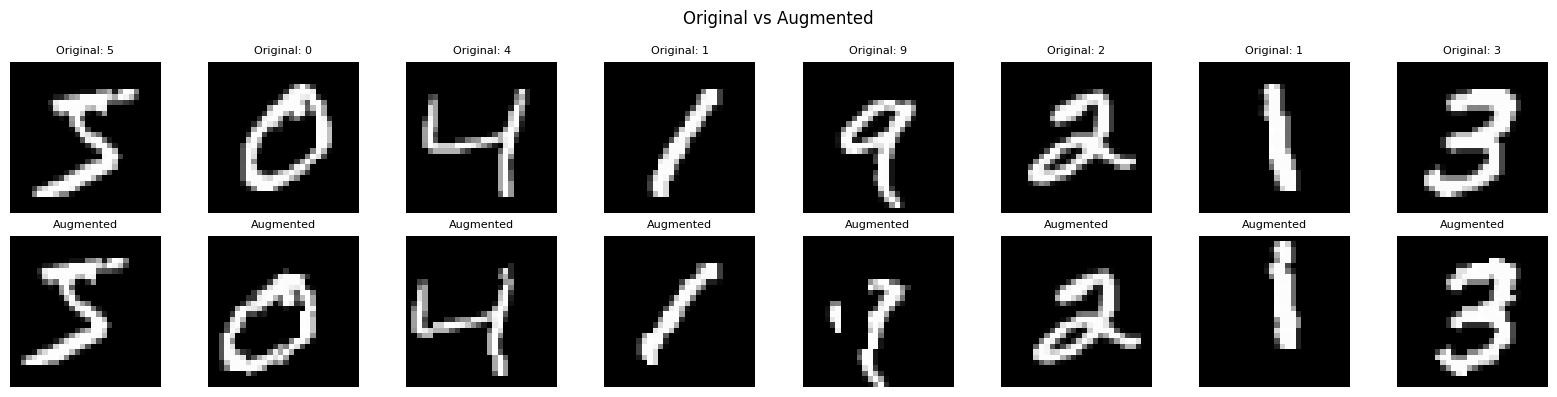

In [7]:
# Visualisera augmented samples
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
raw_set = dataset_cls(root="./data", train=True, download=False,
                      transform=transforms.ToTensor())
for i in range(8):
    img_raw, label = raw_set[i]
    img_aug, _    = full_train[i]
    axes[0, i].imshow(img_raw.squeeze(), cmap="gray")
    axes[0, i].set_title(f"Original: {label}", fontsize=8)
    axes[0, i].axis("off")
    axes[1, i].imshow(img_aug.squeeze(), cmap="gray")
    axes[1, i].set_title("Augmented", fontsize=8)
    axes[1, i].axis("off")
plt.suptitle("Original vs Augmented", fontsize=12)
plt.tight_layout()
plt.show()

---
## 3. Modell-arkitekturer (CNN)

Vi definierar **tre modeller** med olika mycket komplexitet (parametrar) för att kunna jämföra:
- `SmallCNN` – 1 conv-lager
- `MediumCNN` – 2 conv-lager
- `LargeCNN` – 3 conv-lager

Varje conv-lager följs av **BatchNorm** + **ReLU** + **MaxPool** – detta är standardmönstret som jag förstår det.

In [8]:
def conv_block(in_ch, out_ch, kernel=3, pool=True):
    """Standard conv-block: Conv → BatchNorm → ReLU → MaxPool"""
    layers = [
        nn.Conv2d(in_ch, out_ch, kernel_size=kernel, padding=kernel//2),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
    ]
    if pool:
        layers.append(nn.MaxPool2d(2))
    return nn.Sequential(*layers)


class SmallCNN(nn.Module):
    """1 conv-lager. Baseline CNN."""
    def __init__(self, in_channels=1, num_classes=10, dropout=0.3):
        super().__init__()
        self.features = nn.Sequential(
            conv_block(in_channels, 32),   # 28→14
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 14 * 14, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


class MediumCNN(nn.Module):
    """2 conv-lager."""
    def __init__(self, in_channels=1, num_classes=10, dropout=0.3):
        super().__init__()
        self.features = nn.Sequential(
            conv_block(in_channels, 32),   # 28→14
            conv_block(32, 64),            # 14→7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 470),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(470, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


class LargeCNN(nn.Module):
    """3 conv-lager. Tredje lagret utan pooling för att inte tappa spatial info."""
    def __init__(self, in_channels=1, num_classes=10, dropout=0.4):
        super().__init__()
        self.features = nn.Sequential(
            conv_block(in_channels, 32),        # 28→14
            conv_block(32, 64),                 # 14→7
            conv_block(64, 128, pool=False),    # 7→7  (inget pooling här)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# Räkna parametrar
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

for name, cls in [("SmallCNN", SmallCNN), ("MediumCNN", MediumCNN), ("LargeCNN", LargeCNN)]:
    m = cls()
    print(f"{name}: {count_params(m):,} parametrar")

SmallCNN: 804,618 parametrar
MediumCNN: 1,498,108 parametrar
LargeCNN: 3,371,850 parametrar


---
## 4. Träningsloop med MLOps

Träningsfunktionen:
- Loggar loss och accuracy per epoch
- Sparar checkpoint varje N epoker
- Sparar alltid den bästa modellen (lägst val_loss)
- Mäter träningstidens längd

In [9]:
# ── Normaliseringskonstanter (används för att denormalisera bilder i TensorBoard) ──
_MEAN = torch.tensor(MEAN).view(-1, 1, 1)
_STD  = torch.tensor(STD).view(-1, 1, 1)

def denorm(imgs):
    """Ångrar normaliseringen så att pixlar hamnar i [0, 1] för visning."""
    return torch.clamp(imgs * _STD + _MEAN, 0.0, 1.0)


# ── Träningsloop ──────────────────────────────────────────────────────────────

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y)
        correct    += (out.argmax(1) == y).sum().item()
        total      += len(y)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        out = model(X)
        loss = criterion(out, y)
        total_loss += loss.item() * len(y)
        correct    += (out.argmax(1) == y).sum().item()
        total      += len(y)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_with_misses(model, loader, criterion, max_misses=16):
    """
    Kör validering och samlar:
      - loss och accuracy (som eval_epoch)
      - upp till max_misses felklassificerade bilder
      - alla sanna labels och prediktioner (för confusion matrix + per-class acc)
    """
    model.eval()
    total_loss, correct, total = 0, 0, 0
    miss_imgs, miss_true, miss_pred = [], [], []
    all_true, all_pred = [], []
    n_misses = 0

    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        out   = model(X)
        loss  = criterion(out, y)
        preds = out.argmax(1)

        all_true.append(y.cpu())
        all_pred.append(preds.cpu())

        # Samla felklassificerade
        mask = preds != y
        if n_misses < max_misses:
            take = min(mask.sum().item(), max_misses - n_misses)
            miss_imgs.append(X[mask][:take].cpu())
            miss_true.append(y[mask][:take].cpu())
            miss_pred.append(preds[mask][:take].cpu())
            n_misses += take

        total_loss += loss.item() * len(y)
        correct    += (preds == y).sum().item()
        total      += len(y)

    miss_imgs = torch.cat(miss_imgs) if miss_imgs else torch.empty(0)
    miss_true = torch.cat(miss_true) if miss_true else torch.empty(0, dtype=torch.long)
    miss_pred = torch.cat(miss_pred) if miss_pred else torch.empty(0, dtype=torch.long)
    all_true  = torch.cat(all_true)
    all_pred  = torch.cat(all_pred)

    return (total_loss / total, correct / total,
            miss_imgs, miss_true, miss_pred,
            all_true, all_pred)


# ── TensorBoard figure helpers ────────────────────────────────────────────────

def make_miss_figure(miss_imgs, miss_true, miss_pred, classes=None):
    """Skapar ett matplotlib-figure med ett rutnät av felklassificerade bilder."""
    n = len(miss_imgs)
    if n == 0:
        return None
    cols = min(n, 8)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.6, rows * 1.9))
    axes = np.array(axes).flatten()
    imgs_disp = denorm(miss_imgs)  # [N, C, H, W] i [0,1]
    for i in range(n):
        img = imgs_disp[i].squeeze().numpy()
        axes[i].imshow(img, cmap="gray", vmin=0, vmax=1)
        true_lbl = classes[miss_true[i]] if classes else str(miss_true[i].item())
        pred_lbl = classes[miss_pred[i]] if classes else str(miss_pred[i].item())
        axes[i].set_title(f"Sant: {true_lbl}\nGissade: {pred_lbl}", fontsize=7, color="red")
        axes[i].axis("off")
    for i in range(n, len(axes)):
        axes[i].axis("off")
    fig.suptitle("Felklassificerade valideringsbilder", fontsize=9)
    fig.tight_layout()
    return fig


def make_confusion_figure(all_true, all_pred, num_classes=10):
    """Skapar en confusion matrix som matplotlib-figure."""
    cm = torch.zeros(num_classes, num_classes, dtype=torch.long)
    for t, p in zip(all_true, all_pred):
        cm[t, p] += 1
    cm_norm = cm.float() / cm.sum(dim=1, keepdim=True).clamp(min=1)  # rad-normaliserad

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm_norm.numpy(), vmin=0, vmax=1, cmap="Blues")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xlabel("Predikterad klass")
    ax.set_ylabel("Sann klass")
    ax.set_title("Confusion Matrix (rad-normaliserad)")
    ax.set_xticks(range(num_classes))
    ax.set_yticks(range(num_classes))
    # Skriv in värden i varje cell
    for i in range(num_classes):
        for j in range(num_classes):
            val = cm_norm[i, j].item()
            color = "white" if val > 0.6 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=6, color=color)
    fig.tight_layout()
    return fig


def make_perclass_figure(all_true, all_pred, num_classes=10):
    """Skapar ett stapeldiagram med accuracy per klass."""
    per_class_correct = torch.zeros(num_classes)
    per_class_total   = torch.zeros(num_classes)
    for t, p in zip(all_true, all_pred):
        per_class_total[t]   += 1
        per_class_correct[t] += int(t == p)
    acc_per_class = (per_class_correct / per_class_total.clamp(min=1)).numpy()

    fig, ax = plt.subplots(figsize=(6, 3))
    bars = ax.bar(range(num_classes), acc_per_class, color="steelblue")
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Klass")
    ax.set_ylabel("Accuracy")
    ax.set_title("Accuracy per klass (validering)")
    ax.set_xticks(range(num_classes))
    ax.axhline(acc_per_class.mean(), linestyle="--", color="red", linewidth=1,
               label=f"Medel: {acc_per_class.mean():.3f}")
    ax.legend(fontsize=8)
    for bar, acc in zip(bars, acc_per_class):
        ax.text(bar.get_x() + bar.get_width() / 2, acc + 0.01,
                f"{acc:.2f}", ha="center", va="bottom", fontsize=7)
    fig.tight_layout()
    return fig


# ── Huvud-träningsfunktion ────────────────────────────────────────────────────

def train(model, config: dict, run_name: str):
    """
    Komplett träning med MLOps:
      - Skapar run-mapp och sparar config
      - Sparar checkpoints var CKPT_EVERY epoch
      - Sparar alltid bästa modellen
      - Loggar till TensorBoard (starta med: tensorboard --logdir runs)
        * Scalars:    Loss, Accuracy, LR
        * Images:     Felklassificerade bilder, Confusion matrix, Per-class accuracy
        * Histograms: Vikter och gradienter per lager
        * Graphs:     Modellarkitektur
      - Returnerar historik (för plot)
    """
    run_dir = create_run_dir(run_name)
    save_run_config(config, run_dir)

    writer = SummaryWriter(log_dir=run_dir)

    train_loader = DataLoader(train_set, batch_size=config["batch_size"], shuffle=True,  num_workers=2)
    val_loader   = DataLoader(val_set,   batch_size=config["batch_size"], shuffle=False, num_workers=2)

    model = model.to(DEVICE)
    optimizer = optim.Adam(model.parameters(),
                           lr=config["lr"],
                           weight_decay=config.get("weight_decay", 1e-4))
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config["epochs"])
    criterion = nn.CrossEntropyLoss()

    # Logga modellgraf med en dummy-batch
    dummy_input = next(iter(train_loader))[0][:1].to(DEVICE)
    writer.add_graph(model, dummy_input)

    # Hur ofta visuella loggar (bilder/histogram) sparas
    LOG_IMAGES_EVERY = config.get("log_images_every", 5)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss = float("inf")
    start_time = time.time()

    for epoch in range(1, config["epochs"] + 1):
        t_loss, t_acc = train_epoch(model, train_loader, optimizer, criterion)

        # Kör utökad validering på bild-epoker, annars snabb
        log_visual = (epoch % LOG_IMAGES_EVERY == 0) or (epoch == config["epochs"])
        if log_visual:
            v_loss, v_acc, miss_imgs, miss_true, miss_pred, all_true, all_pred = \
                eval_with_misses(model, val_loader, criterion)
        else:
            v_loss, v_acc = eval_epoch(model, val_loader, criterion)

        scheduler.step()

        history["train_loss"].append(t_loss)
        history["val_loss"].append(v_loss)
        history["train_acc"].append(t_acc)
        history["val_acc"].append(v_acc)

        # --- Scalars (varje epok) ---
        writer.add_scalars("Loss",     {"train": t_loss, "val": v_loss}, epoch)
        writer.add_scalars("Accuracy", {"train": t_acc,  "val": v_acc},  epoch)
        writer.add_scalar("LR", scheduler.get_last_lr()[0], epoch)

        # --- Vikter + gradienter (varje epok) ---
        for name, param in model.named_parameters():
            if param.requires_grad:
                writer.add_histogram(f"Weights/{name}", param.data, epoch)
                if param.grad is not None:
                    writer.add_histogram(f"Grads/{name}", param.grad, epoch)

        # --- Visuella loggar (var LOG_IMAGES_EVERY epok) ---
        if log_visual:
            # 1. Felklassificerade bilder
            fig_miss = make_miss_figure(miss_imgs, miss_true, miss_pred)
            if fig_miss is not None:
                writer.add_figure("Misclassified", fig_miss, epoch)
                plt.close(fig_miss)

            # 2. Confusion matrix
            fig_cm = make_confusion_figure(all_true, all_pred)
            writer.add_figure("ConfusionMatrix", fig_cm, epoch)
            plt.close(fig_cm)

            # 3. Per-class accuracy
            fig_pc = make_perclass_figure(all_true, all_pred)
            writer.add_figure("PerClassAccuracy", fig_pc, epoch)
            plt.close(fig_pc)

        is_best = v_loss < best_val_loss
        if is_best:
            best_val_loss = v_loss

        # Spara checkpoint var CKPT_EVERY epoch, samt vid ny bästa
        CKPT_EVERY = config.get("ckpt_every", 5)
        if epoch % CKPT_EVERY == 0 or is_best:
            save_checkpoint(model, optimizer, epoch, v_loss, run_dir, is_best)

        print(f"Epoch {epoch:3d}/{config['epochs']} | "
              f"train_loss={t_loss:.4f} acc={t_acc:.3f} | "
              f"val_loss={v_loss:.4f} acc={v_acc:.3f}"
              + (" ⭐" if is_best else "")
              + (" 📊" if log_visual else ""))

    elapsed = time.time() - start_time
    print(f"\n⏱️  Total träningsid: {elapsed:.1f}s ({elapsed/config['epochs']:.1f}s/epoch)")

    writer.flush()
    writer.close()
    print(f"📊 TensorBoard-loggar sparade i: {run_dir}")
    print(f"   Starta med: tensorboard --logdir runs")

    # Spara historik
    with open(os.path.join(run_dir, "history.json"), "w") as f:
        json.dump(history, f, indent=2)

    return history, run_dir

---
## 5. Visualiseringshjälpare

In [10]:
def plot_conv_filters(model, layer_name="features.0"):
    """Visualiserar conv-filter-vikterna i ett lager."""
    layer = dict(model.named_modules()).get(layer_name + ".0")  # Conv2d är [0] i blocket
    if layer is None or not isinstance(layer, nn.Conv2d):
        print("Hittade inte Conv2d-lagret. Kontrollera layer_name.")
        return
    weights = layer.weight.data.cpu()
    n = min(weights.shape[0], 32)
    cols = 8
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.5, rows * 1.5))
    axes = np.array(axes).flatten()
    for i in range(n):
        w = weights[i, 0]  # första input-kanalen
        axes[i].imshow(w, cmap="RdBu_r", vmin=-w.abs().max(), vmax=w.abs().max())
        axes[i].axis("off")
    for i in range(n, len(axes)):
        axes[i].axis("off")
    plt.suptitle(f"Conv-filter vikter – {layer_name}", fontsize=12)
    plt.tight_layout()
    plt.show()

In [11]:


def summarize_histories(histories: dict, configs: dict = None):
    rows = []

    for name, h in histories.items():
        best_val_loss_epoch = int(np.argmin(h["val_loss"])) + 1
        best_val_acc_epoch  = int(np.argmax(h["val_acc"])) + 1

        row = {
            "run": name,
            "best_val_loss": min(h["val_loss"]),
            "epoch_best_val_loss": best_val_loss_epoch,
            "best_val_acc": max(h["val_acc"]),
            "epoch_best_val_acc": best_val_acc_epoch,
            "final_train_acc": h["train_acc"][-1],
            "final_val_acc": h["val_acc"][-1],
            "final_train_loss": h["train_loss"][-1],
            "final_val_loss": h["val_loss"][-1],
            "generalization_gap": h["train_acc"][-1] - h["val_acc"][-1],
        }

        if configs and name in configs:
            for k, v in configs[name].items():
                if k not in row:
                    row[k] = v

        rows.append(row)

    df = pd.DataFrame(rows)
    return df.sort_values("best_val_acc", ascending=False)


def plot_histories_advanced(histories: dict, title="Träningsjämförelse"):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    colors = plt.cm.tab10.colors

    for i, (name, h) in enumerate(histories.items()):
        c = colors[i % len(colors)]
        epochs = range(1, len(h["train_loss"]) + 1)

        # Loss
        axes[0, 0].plot(epochs, h["train_loss"], "--", color=c, alpha=0.7, label=f"{name} train")
        axes[0, 0].plot(epochs, h["val_loss"], "-", color=c, label=f"{name} val")

        # Accuracy
        axes[0, 1].plot(epochs, h["train_acc"], "--", color=c, alpha=0.7, label=f"{name} train")
        axes[0, 1].plot(epochs, h["val_acc"], "-", color=c, label=f"{name} val")

        # Generalization gap = train_acc - val_acc
        gap = np.array(h["train_acc"]) - np.array(h["val_acc"])
        axes[1, 0].plot(epochs, gap, color=c, label=name)

        # Val loss only, enklare att se bästa modell
        axes[1, 1].plot(epochs, h["val_loss"], color=c, label=name)

        best_epoch = int(np.argmin(h["val_loss"])) + 1
        best_loss = min(h["val_loss"])
        axes[1, 1].scatter(best_epoch, best_loss, color=c, s=70)

    axes[0, 0].set_title("Loss")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("Loss")
    axes[0, 0].legend()

    axes[0, 1].set_title("Accuracy")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].set_ylabel("Accuracy")
    axes[0, 1].legend()

    axes[1, 0].set_title("Generalization gap (train_acc - val_acc)")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("Gap")
    axes[1, 0].axhline(0, linestyle="--", linewidth=1)
    axes[1, 0].legend()

    axes[1, 1].set_title("Validation loss (bästa epoch markerad)")
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].set_ylabel("Val loss")
    axes[1, 1].legend()

    plt.suptitle(title, fontsize=15)
    plt.tight_layout()
    plt.show()


def plot_summary_bars(summary_df):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Best val accuracy
    axes[0].bar(summary_df["run"], summary_df["best_val_acc"])
    axes[0].set_title("Bästa validation accuracy")
    axes[0].set_ylabel("Accuracy")
    axes[0].tick_params(axis="x", rotation=20)

    # Best val loss
    axes[1].bar(summary_df["run"], summary_df["best_val_loss"])
    axes[1].set_title("Lägsta validation loss")
    axes[1].set_ylabel("Loss")
    axes[1].tick_params(axis="x", rotation=20)

    # Generalization gap
    axes[2].bar(summary_df["run"], summary_df["generalization_gap"])
    axes[2].set_title("Generalization gap")
    axes[2].set_ylabel("Train acc - Val acc")
    axes[2].tick_params(axis="x", rotation=20)

    plt.tight_layout()
    plt.show()

---
## 6. Kör träning – Jämför arkitekturer

Ändra `EPOCHS` och `BATCH_SIZE` efter behov. Kör alla tre modeller och jämför.

In [12]:
BASE_CONFIG = {
    "epochs":       20,
    "batch_size":   64,
    "lr":           1e-3,
    "weight_decay": 1e-4,
    "dropout":      0.3,
    "ckpt_every":   5,
    "dataset":      DATASET,
}

all_histories = {}
all_configs = {}

# --- SmallCNN ---
print("=" * 50)
print("SmallCNN (1 conv-lager)")
model_small = SmallCNN(dropout=BASE_CONFIG["dropout"])
cfg = {**BASE_CONFIG, "architecture": "SmallCNN"}
hist_small, _ = train(model_small, cfg, "SmallCNN")
all_histories["SmallCNN"] = hist_small
all_configs["SmallCNN"] = cfg

SmallCNN (1 conv-lager)
Run-mapp skapad: runs/20260430_115732_SmallCNN
Config sparad: runs/20260430_115732_SmallCNN/config.json
  💾 Ny bästa checkpoint sparad: epoch 1, val_loss=0.3480
Epoch   1/20 | train_loss=0.7099 acc=0.770 | val_loss=0.3480 acc=0.900 ⭐
  💾 Ny bästa checkpoint sparad: epoch 2, val_loss=0.2277
Epoch   2/20 | train_loss=0.4069 acc=0.871 | val_loss=0.2277 acc=0.926 ⭐
  💾 Ny bästa checkpoint sparad: epoch 3, val_loss=0.2152
Epoch   3/20 | train_loss=0.3438 acc=0.892 | val_loss=0.2152 acc=0.934 ⭐
  💾 Ny bästa checkpoint sparad: epoch 4, val_loss=0.1886
Epoch   4/20 | train_loss=0.3136 acc=0.902 | val_loss=0.1886 acc=0.943 ⭐
  💾 Ny bästa checkpoint sparad: epoch 5, val_loss=0.1809
Epoch   5/20 | train_loss=0.2907 acc=0.908 | val_loss=0.1809 acc=0.945 ⭐ 📊
  💾 Ny bästa checkpoint sparad: epoch 6, val_loss=0.1763
Epoch   6/20 | train_loss=0.2738 acc=0.916 | val_loss=0.1763 acc=0.945 ⭐
  💾 Ny bästa checkpoint sparad: epoch 7, val_loss=0.1612
Epoch   7/20 | train_loss=0.2576 

In [13]:
# --- MediumCNN ---
print("=" * 50)
print("MediumCNN (2 conv-lager)")
model_medium = MediumCNN(dropout=BASE_CONFIG["dropout"])
cfg = {**BASE_CONFIG, "architecture": "MediumCNN"}
hist_medium, _ = train(model_medium, cfg, "MediumCNN")
all_histories["MediumCNN"] = hist_medium
all_configs["MediumCNN"] = cfg

MediumCNN (2 conv-lager)
Run-mapp skapad: runs/20260430_120009_MediumCNN
Config sparad: runs/20260430_120009_MediumCNN/config.json
  💾 Ny bästa checkpoint sparad: epoch 1, val_loss=0.1636
Epoch   1/20 | train_loss=0.3640 acc=0.883 | val_loss=0.1636 acc=0.945 ⭐
  💾 Ny bästa checkpoint sparad: epoch 2, val_loss=0.1190
Epoch   2/20 | train_loss=0.1853 acc=0.942 | val_loss=0.1190 acc=0.962 ⭐
  💾 Ny bästa checkpoint sparad: epoch 3, val_loss=0.1066
Epoch   3/20 | train_loss=0.1540 acc=0.952 | val_loss=0.1066 acc=0.965 ⭐
  💾 Ny bästa checkpoint sparad: epoch 4, val_loss=0.0924
Epoch   4/20 | train_loss=0.1318 acc=0.959 | val_loss=0.0924 acc=0.970 ⭐
  💾 Ny bästa checkpoint sparad: epoch 5, val_loss=0.0855
Epoch   5/20 | train_loss=0.1215 acc=0.962 | val_loss=0.0855 acc=0.972 ⭐ 📊
Epoch   6/20 | train_loss=0.1128 acc=0.965 | val_loss=0.0856 acc=0.972
  💾 Ny bästa checkpoint sparad: epoch 7, val_loss=0.0747
Epoch   7/20 | train_loss=0.1002 acc=0.968 | val_loss=0.0747 acc=0.976 ⭐
  💾 Ny bästa che

In [14]:
# --- LargeCNN ---
print("=" * 50)
print("LargeCNN (3 conv-lager)")
model_large = LargeCNN(dropout=0.4)
cfg = {**BASE_CONFIG, "architecture": "LargeCNN", "dropout": 0.4}
hist_large, run_dir_large = train(model_large, cfg, "LargeCNN")
all_histories["LargeCNN"] = hist_large
all_configs["LargeCNN"] = cfg

LargeCNN (3 conv-lager)
Run-mapp skapad: runs/20260430_120241_LargeCNN
Config sparad: runs/20260430_120241_LargeCNN/config.json


  💾 Ny bästa checkpoint sparad: epoch 1, val_loss=0.1749
Epoch   1/20 | train_loss=0.3270 acc=0.897 | val_loss=0.1749 acc=0.947 ⭐
  💾 Ny bästa checkpoint sparad: epoch 2, val_loss=0.1071
Epoch   2/20 | train_loss=0.1644 acc=0.951 | val_loss=0.1071 acc=0.967 ⭐
Epoch   3/20 | train_loss=0.1352 acc=0.959 | val_loss=0.1108 acc=0.966
  💾 Ny bästa checkpoint sparad: epoch 4, val_loss=0.0866
Epoch   4/20 | train_loss=0.1185 acc=0.966 | val_loss=0.0866 acc=0.975 ⭐
Epoch   5/20 | train_loss=0.1103 acc=0.966 | val_loss=0.1026 acc=0.969 📊
Epoch   6/20 | train_loss=0.1025 acc=0.969 | val_loss=0.0873 acc=0.973
  💾 Ny bästa checkpoint sparad: epoch 7, val_loss=0.0667
Epoch   7/20 | train_loss=0.0934 acc=0.973 | val_loss=0.0667 acc=0.979 ⭐
Epoch   8/20 | train_loss=0.0850 acc=0.975 | val_loss=0.0753 acc=0.976
  💾 Ny bästa checkpoint sparad: epoch 9, val_loss=0.0566
Epoch   9/20 | train_loss=0.0788 acc=0.977 | val_loss=0.0566 acc=0.982 ⭐
Epoch  10/20 | train_loss=0.0720 acc=0.979 | val_loss=0.0631 acc

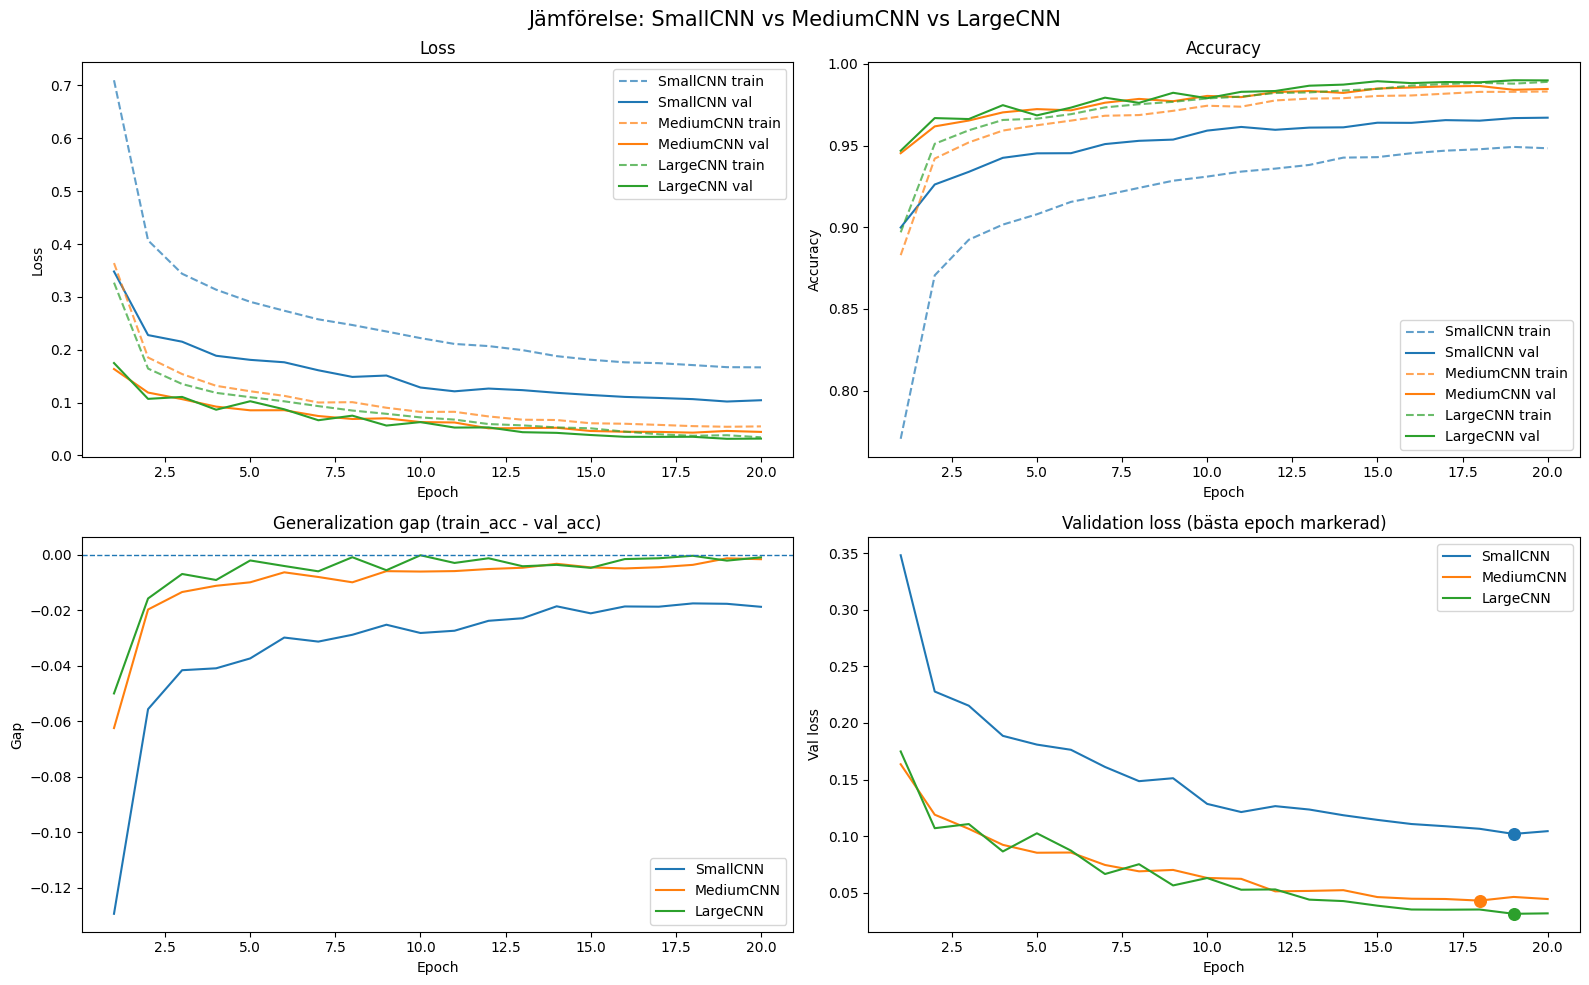

,run,best_val_loss,epoch_best_val_loss,best_val_acc,epoch_best_val_acc,final_train_acc,final_val_acc,final_train_loss,final_val_loss,generalization_gap,epochs,batch_size,lr,weight_decay,dropout,ckpt_every,dataset,architecture
2,LargeCNN,0.031559,19,0.990000,19,0.989021,0.989917,0.034422,0.031941,-0.000896,20,64,0.001,0.0001,0.4,5,MNIST,LargeCNN
1,MediumCNN,0.043203,18,0.986500,18,0.983104,0.984667,0.055040,0.044590,-0.001563,20,64,0.001,0.0001,0.3,5,MNIST,MediumCNN
0,SmallCNN,0.102062,19,0.967083,20,0.948354,0.967083,0.166725,0.104507,-0.018729,20,64,0.001,0.0001,0.3,5,MNIST,SmallCNN


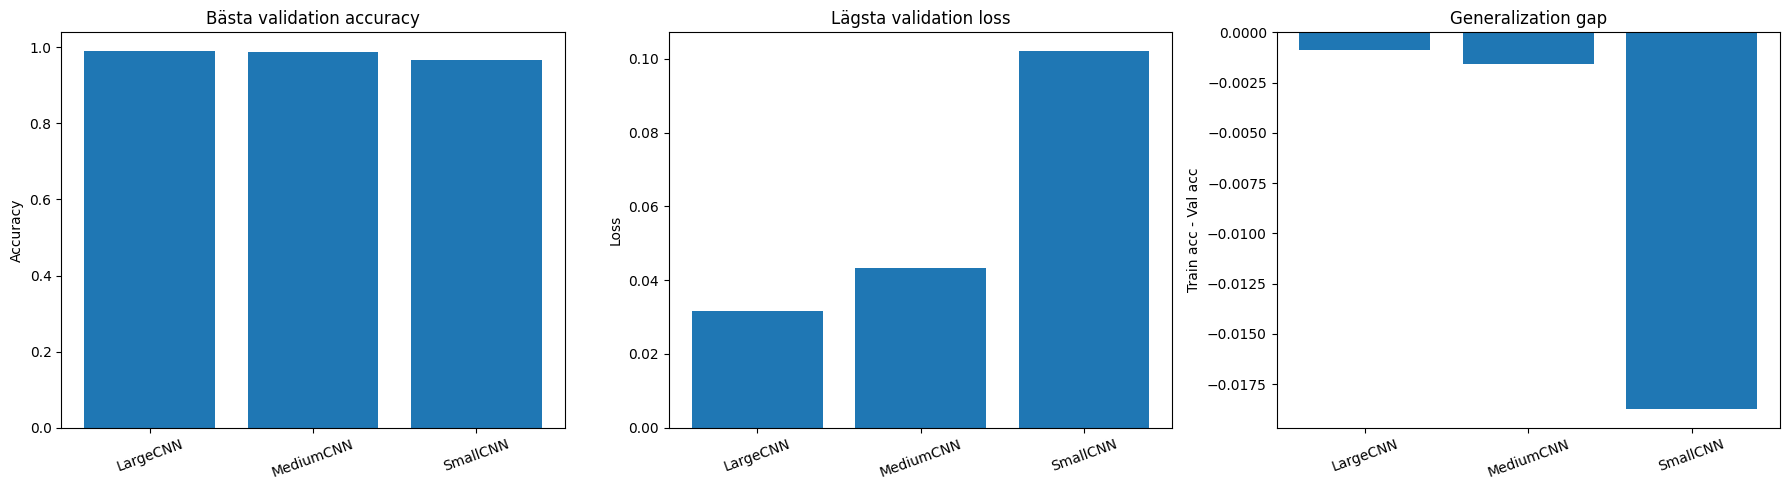

In [15]:
plot_histories_advanced(all_histories, title="Jämförelse: SmallCNN vs MediumCNN vs LargeCNN")

summary_df = summarize_histories(all_histories, all_configs)
display(summary_df)

plot_summary_bars(summary_df)

### Försök att göra overfitting lite mer tydligt

In [16]:
def print_run_insights(summary_df):
    best_row = summary_df.iloc[0]
    print(f"Bäst validation accuracy: {best_row['run']} ({best_row['best_val_acc']:.4f})")
    print(f"Bästa epoch för den körningen: {best_row['epoch_best_val_acc']}")
    print()

    for _, row in summary_df.iterrows():
        print(f"{row['run']}:")
        print(f"  best_val_acc = {row['best_val_acc']:.4f}")
        print(f"  best_val_loss = {row['best_val_loss']:.4f}")
        print(f"  generalization_gap = {row['generalization_gap']:.4f}")

        if row["generalization_gap"] > 0.05:
            print("  → Trolig overfitting")
        else:
            print("  → Relativt bra generalisering")
        print()

In [17]:
print_run_insights(summary_df)

Bäst validation accuracy: LargeCNN (0.9900)
Bästa epoch för den körningen: 19

LargeCNN:
  best_val_acc = 0.9900
  best_val_loss = 0.0316
  generalization_gap = -0.0009
  → Relativt bra generalisering

MediumCNN:
  best_val_acc = 0.9865
  best_val_loss = 0.0432
  generalization_gap = -0.0016
  → Relativt bra generalisering

SmallCNN:
  best_val_acc = 0.9671
  best_val_loss = 0.1021
  generalization_gap = -0.0187
  → Relativt bra generalisering



---
## 7. Utvärdering på testdata

Ladda den **bästa checkpointen** (lägst val_loss) och utvärdera på testdata.

In [18]:
test_loader = DataLoader(test_set, batch_size=256, shuffle=False, num_workers=2)

@torch.no_grad()
def evaluate_test(model, loader):
    model.eval().to(DEVICE)
    correct, total = 0, 0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        out = model(X)
        correct += (out.argmax(1) == y).sum().item()
        total   += len(y)
    return correct / total

# Ladda bästa LargeCNN och testa
best_ckpt = os.path.join(run_dir_large, "checkpoints", "best_model.pt")
model_best = LargeCNN().to(DEVICE)
opt_tmp    = optim.Adam(model_best.parameters())
load_checkpoint(model_best, opt_tmp, best_ckpt)

acc = evaluate_test(model_best, test_loader)
print(f"\n🎯 Test accuracy (bästa LargeCNN): {acc:.4f} ({acc*100:.2f}%)")

Laddade checkpoint från epoch 19, val_loss=0.0316

🎯 Test accuracy (bästa LargeCNN): 0.9962 (99.62%)


### Per-class accuracy: vilket siffra är modellen bäst/sämst på?

Per-klass accuracy:
  Klass 0: 0.9980
  Klass 1: 0.9991 ← BÄST
  Klass 2: 0.9981
  Klass 3: 0.9970
  Klass 4: 0.9980
  Klass 5: 0.9910 ← SÄMST
  Klass 6: 0.9958
  Klass 7: 0.9961
  Klass 8: 0.9949
  Klass 9: 0.9931


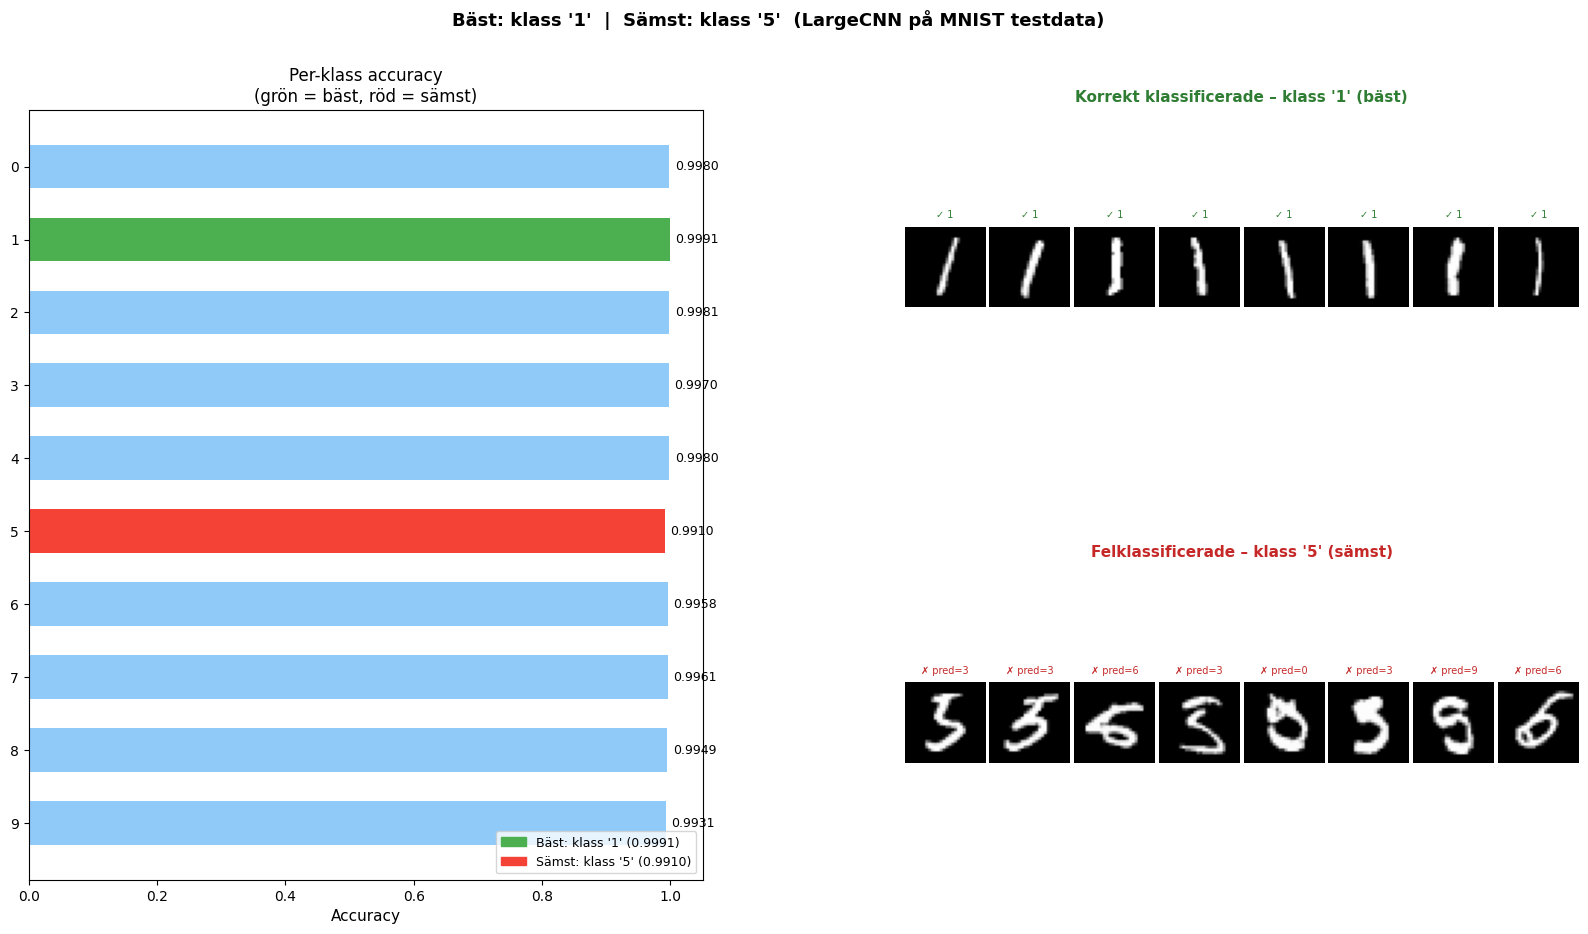

In [19]:


# Klasser för MNIST (kan bytas ut om annat dataset används)
CLASS_NAMES = [str(i) for i in range(10)]

# --- Samla alla prediktioner och sanna etiketter ---
all_preds  = []
all_labels = []
all_images = []   # spara råa (onormerade) bilder för visualisering

raw_test = dataset_cls(root="./data", train=False, download=False,
                       transform=transforms.ToTensor())
raw_loader = DataLoader(raw_test, batch_size=256, shuffle=False, num_workers=2)

model_best.eval()
with torch.no_grad():
    for (X_raw, y), (X_norm, _) in zip(raw_loader,
                                        DataLoader(test_set, batch_size=256,
                                                   shuffle=False, num_workers=2)):
        X_norm = X_norm.to(DEVICE)
        preds  = model_best(X_norm).argmax(1).cpu()
        all_preds.append(preds)
        all_labels.append(y)
        all_images.append(X_raw)

all_preds  = torch.cat(all_preds)
all_labels = torch.cat(all_labels)
all_images = torch.cat(all_images)

# --- Beräkna per-klass accuracy ---
n_classes = len(CLASS_NAMES)
class_correct = torch.zeros(n_classes)
class_total   = torch.zeros(n_classes)
for pred, label in zip(all_preds, all_labels):
    class_total[label]   += 1
    class_correct[label] += (pred == label).float()

per_class_acc = (class_correct / class_total).numpy()

best_class  = int(np.argmax(per_class_acc))
worst_class = int(np.argmin(per_class_acc))

print("Per-klass accuracy:")
for i, acc in enumerate(per_class_acc):
    tag = " ← BÄST" if i == best_class else (" ← SÄMST" if i == worst_class else "")
    print(f"  Klass {CLASS_NAMES[i]}: {acc:.4f}{tag}")

# --- Samla exempelbilder ---
N_EXAMPLES = 8

# Korrekt klassificerade bilder av den bästa klassen
correct_mask  = (all_preds == all_labels) & (all_labels == best_class)
correct_imgs  = all_images[correct_mask][:N_EXAMPLES]

# Felklassificerade bilder av den sämsta klassen, med vilken klass de fel-predikterades som
wrong_mask    = (all_preds != all_labels) & (all_labels == worst_class)
wrong_imgs    = all_images[wrong_mask][:N_EXAMPLES]
wrong_preds   = all_preds[wrong_mask][:N_EXAMPLES]

# ── Visualisering ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 10))
gs  = fig.add_gridspec(2, 2, height_ratios=[1, 1], hspace=0.45, wspace=0.3)

# Panel 1 (vänster, sträcker sig över båda raderna): stapeldiagram
ax_bar = fig.add_subplot(gs[:, 0])
bar_colors = ["#4caf50" if i == best_class
              else "#f44336" if i == worst_class
              else "#90caf9"
              for i in range(n_classes)]
bars = ax_bar.barh(CLASS_NAMES, per_class_acc, color=bar_colors, height=0.6)
ax_bar.bar_label(bars, fmt="%.4f", padding=4, fontsize=9)
ax_bar.set_xlim(0, 1.05)
ax_bar.set_xlabel("Accuracy", fontsize=11)
ax_bar.set_title("Per-klass accuracy\n(grön = bäst, röd = sämst)", fontsize=12)
ax_bar.invert_yaxis()

from matplotlib.patches import Patch
ax_bar.legend(handles=[Patch(color="#4caf50", label=f"Bäst: klass '{CLASS_NAMES[best_class]}' "
                                                     f"({per_class_acc[best_class]:.4f})"),
                        Patch(color="#f44336", label=f"Sämst: klass '{CLASS_NAMES[worst_class]}' "
                                                     f"({per_class_acc[worst_class]:.4f})")],
              fontsize=9, loc="lower right")

# Panel 2 (höger uppe): korrekt klassificerade bilder av bästa klassen
ax_top = fig.add_subplot(gs[0, 1])
ax_top.axis("off")
ax_top.set_title(f"Korrekt klassificerade – klass '{CLASS_NAMES[best_class]}' (bäst)",
                 fontsize=11, color="#2e7d32", fontweight="bold")

n_show = len(correct_imgs)
sub_gs = gs[0, 1].subgridspec(1, N_EXAMPLES, wspace=0.05)
for j in range(N_EXAMPLES):
    ax = fig.add_subplot(sub_gs[0, j])
    if j < n_show:
        ax.imshow(correct_imgs[j].squeeze(), cmap="gray")
        ax.set_title(f"✓ {CLASS_NAMES[best_class]}", fontsize=7, color="#2e7d32")
    ax.axis("off")

# Panel 3 (höger nere): felklassificerade bilder av sämsta klassen
ax_bot = fig.add_subplot(gs[1, 1])
ax_bot.axis("off")
ax_bot.set_title(f"Felklassificerade – klass '{CLASS_NAMES[worst_class]}' (sämst)",
                 fontsize=11, color="#c62828", fontweight="bold")

n_show_w = len(wrong_imgs)
sub_gs2  = gs[1, 1].subgridspec(1, N_EXAMPLES, wspace=0.05)
for j in range(N_EXAMPLES):
    ax = fig.add_subplot(sub_gs2[0, j])
    if j < n_show_w:
        ax.imshow(wrong_imgs[j].squeeze(), cmap="gray")
        ax.set_title(f"✗ pred={CLASS_NAMES[wrong_preds[j]]}", fontsize=7, color="#c62828")
    ax.axis("off")

plt.suptitle(
    f"Bäst: klass '{CLASS_NAMES[best_class]}'  |  Sämst: klass '{CLASS_NAMES[worst_class]}'  "
    f"(LargeCNN på {DATASET} testdata)",
    fontsize=13, fontweight="bold",
)
plt.show()


---
## 8. Visualisera conv-filter

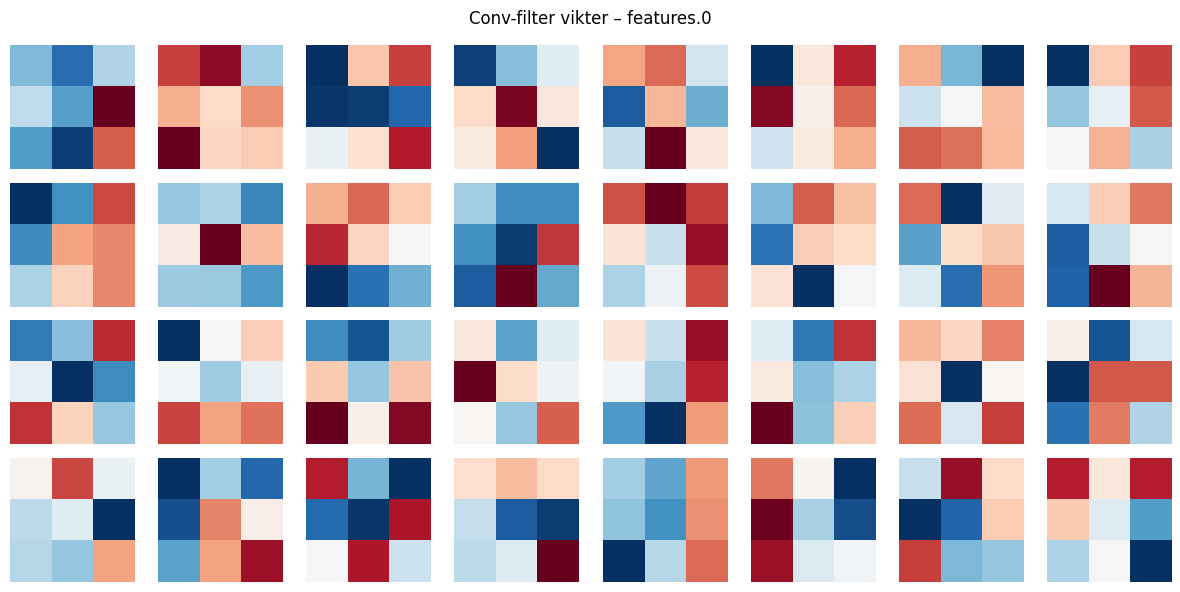

In [20]:
plot_conv_filters(model_best, layer_name="features.0")

---
## 8.1. 🚀 TensorBoard – Träningsövervakning

TensorBoard loggas automatiskt under träning till varje runs/-mapp.

**Starta TensorBoard i en terminal:**
```bash
tensorboard --logdir runs
```
Öppna sedan [http://localhost:6006](http://localhost:6006) i din webbläsare.

Du kan också starta det inline i notebooken med cellen nedan.

In [21]:
# Starta TensorBoard inline i notebooken
# Körs i bakgrunden – öppna http://localhost:6006 i webbläsaren
# (eller klicka på länken som visas nedan)
%load_ext tensorboard
%tensorboard --logdir runs
print("http://localhost:6006")

http://localhost:6006


---
## 9. 🚀 Överkurs – Hyper-parameter tuning

Definiera en lista med konfigurationer och träna modeller automatiskt för alla.

In [22]:
# Lista med hyperparameter-kombinationer att testa
HP_GRID = [
    {"epochs": 15, "batch_size": 64, "lr": 1e-3,  "weight_decay": 1e-4, "dropout": 0.3, "ckpt_every": 5},
    {"epochs": 15, "batch_size": 64, "lr": 5e-4,  "weight_decay": 1e-4, "dropout": 0.3, "ckpt_every": 5},
    {"epochs": 15, "batch_size": 64, "lr": 1e-3,  "weight_decay": 1e-3, "dropout": 0.4, "ckpt_every": 5},
    {"epochs": 15, "batch_size": 128,"lr": 1e-3,  "weight_decay": 1e-4, "dropout": 0.2, "ckpt_every": 5},
    {"epochs": 15, "batch_size": 32, "lr": 2e-3,  "weight_decay": 5e-4, "dropout": 0.3, "ckpt_every": 5},
]

hp_results = []

for i, cfg in enumerate(HP_GRID):
    cfg["dataset"] = DATASET
    cfg["architecture"] = "MediumCNN"
    run_name = f"hp_run_{i+1:02d}"
    print(f"\n{'='*50}")
    print(f"Körning {i+1}/{len(HP_GRID)}: lr={cfg['lr']}, bs={cfg['batch_size']}, dropout={cfg['dropout']}")

    model = MediumCNN(dropout=cfg["dropout"])
    hist, run_dir = train(model, cfg, run_name)

    best_val_acc = max(hist["val_acc"])
    hp_results.append({"run": run_name, "config": cfg, "best_val_acc": best_val_acc, "run_dir": run_dir})
    print(f"  → Bästa val_acc: {best_val_acc:.4f}")

# Sortera och visa bästa körning
hp_results.sort(key=lambda x: -x["best_val_acc"])
print("\n🏆 Resultat (bäst → sämst):")
for r in hp_results:
    c = r["config"]
    print(f"  {r['run']}: val_acc={r['best_val_acc']:.4f} | lr={c['lr']}, bs={c['batch_size']}, dropout={c['dropout']}")


Körning 1/5: lr=0.001, bs=64, dropout=0.3
Run-mapp skapad: runs/20260430_120515_hp_run_01
Config sparad: runs/20260430_120515_hp_run_01/config.json


  💾 Ny bästa checkpoint sparad: epoch 1, val_loss=0.1689
Epoch   1/15 | train_loss=0.3482 acc=0.891 | val_loss=0.1689 acc=0.946 ⭐
  💾 Ny bästa checkpoint sparad: epoch 2, val_loss=0.1142
Epoch   2/15 | train_loss=0.1739 acc=0.946 | val_loss=0.1142 acc=0.966 ⭐
  💾 Ny bästa checkpoint sparad: epoch 3, val_loss=0.1034
Epoch   3/15 | train_loss=0.1488 acc=0.953 | val_loss=0.1034 acc=0.968 ⭐
  💾 Ny bästa checkpoint sparad: epoch 4, val_loss=0.0894
Epoch   4/15 | train_loss=0.1291 acc=0.960 | val_loss=0.0894 acc=0.972 ⭐
Epoch   5/15 | train_loss=0.1169 acc=0.963 | val_loss=0.0899 acc=0.971 📊
Epoch   6/15 | train_loss=0.1071 acc=0.966 | val_loss=0.0931 acc=0.968
  💾 Ny bästa checkpoint sparad: epoch 7, val_loss=0.0751
Epoch   7/15 | train_loss=0.0967 acc=0.970 | val_loss=0.0751 acc=0.976 ⭐
  💾 Ny bästa checkpoint sparad: epoch 8, val_loss=0.0694
Epoch   8/15 | train_loss=0.0867 acc=0.974 | val_loss=0.0694 acc=0.977 ⭐
  💾 Ny bästa checkpoint sparad: epoch 9, val_loss=0.0605
Epoch   9/15 | trai

/tmp/ipykernel_81855/344393827.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


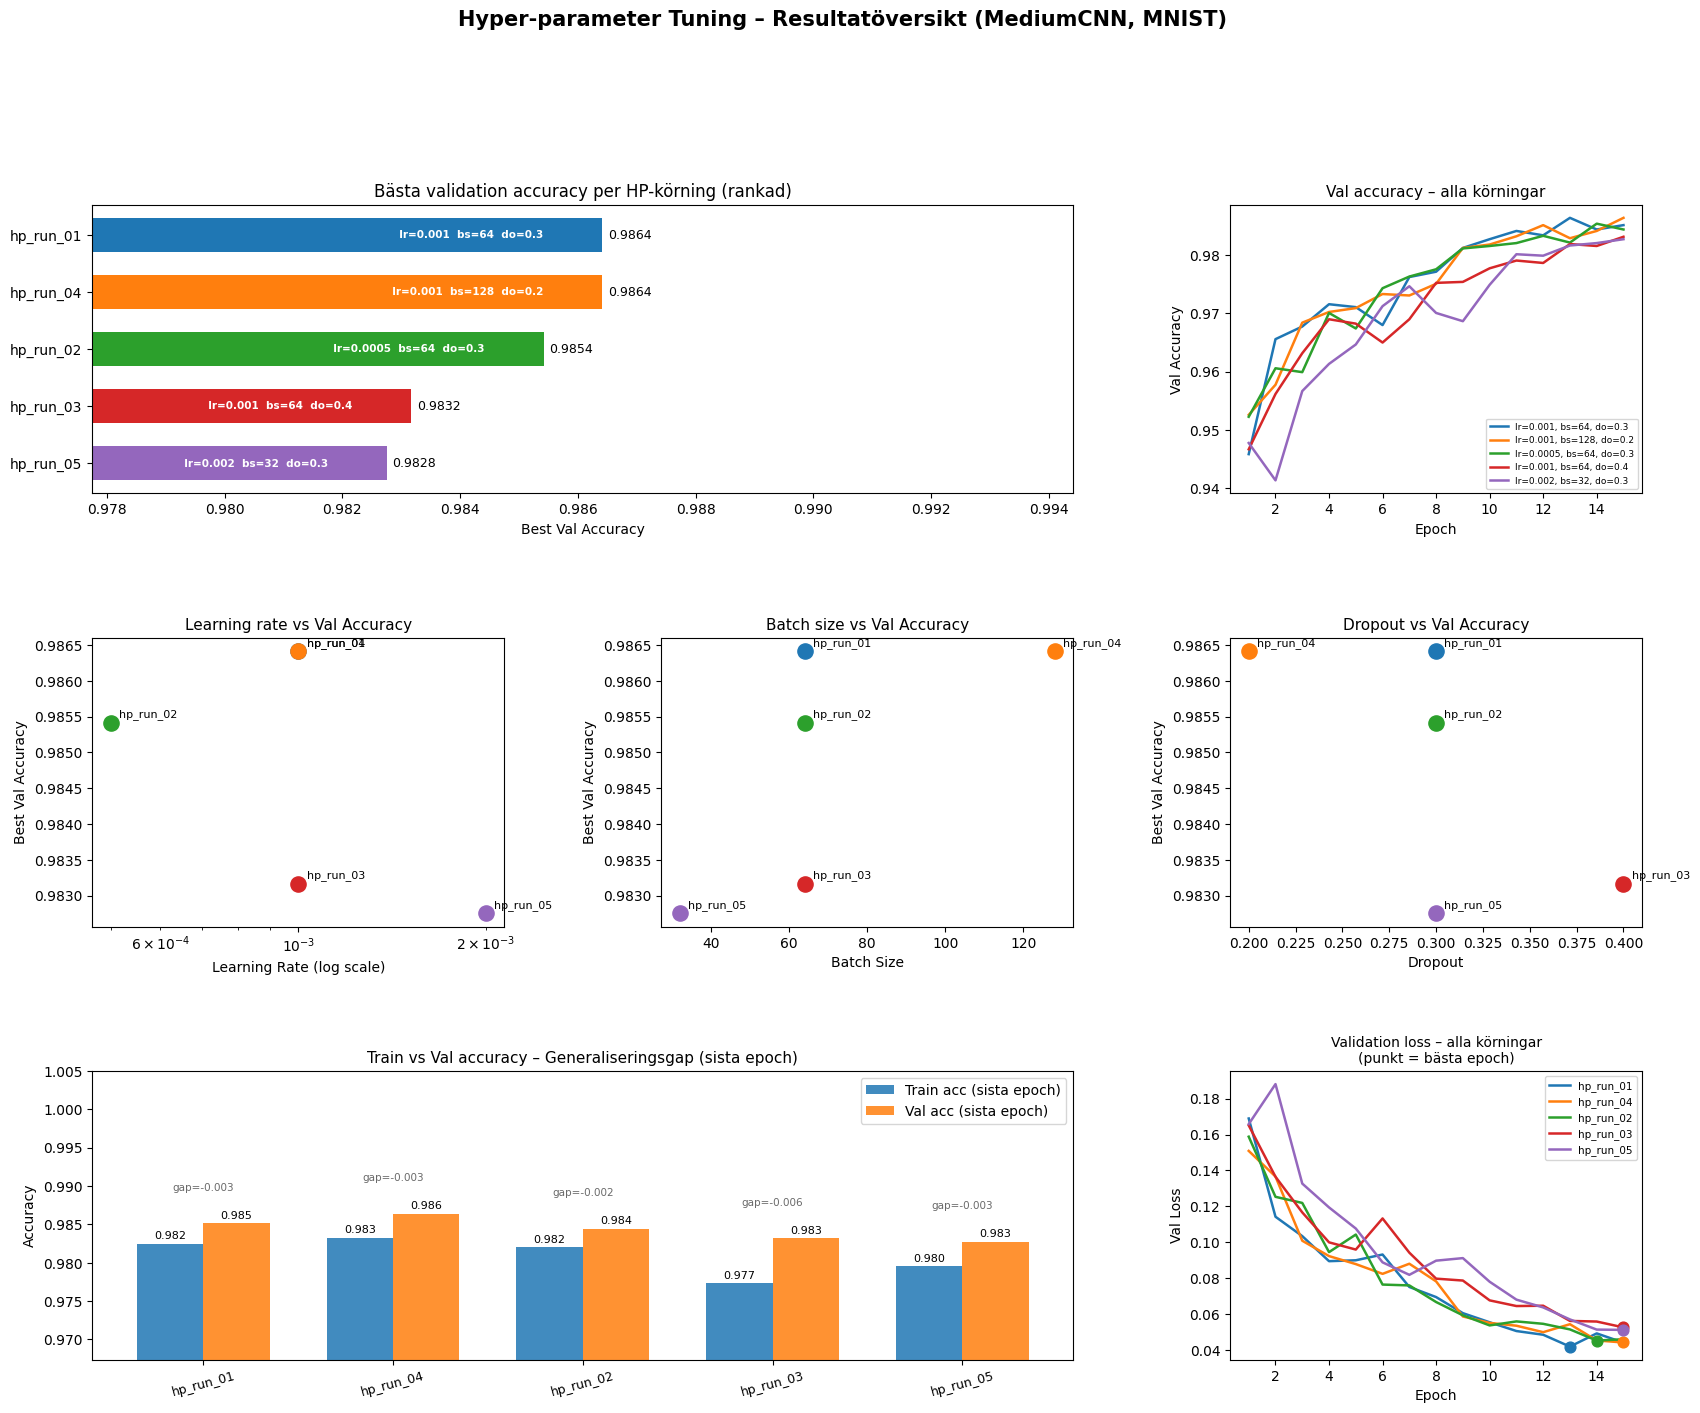


Sammanfattning (sorterat efter bästa val_acc):


,run,lr,batch_size,dropout,weight_decay,best_val_acc,generalization_gap
0,hp_run_01,0.0010,64,0.3,0.0001,0.986417,-0.002708
1,hp_run_04,0.0010,128,0.2,0.0001,0.986417,-0.003146
2,hp_run_02,0.0005,64,0.3,0.0001,0.985417,-0.002396
3,hp_run_03,0.0010,64,0.4,0.0010,0.983167,-0.005812
4,hp_run_05,0.0020,32,0.3,0.0005,0.982750,-0.003188


In [23]:

# --- Ladda historik från disk ---
hp_histories = {}
for r in hp_results:
    hist_path = os.path.join(r["run_dir"], "history.json")
    with open(hist_path) as f:
        hp_histories[r["run"]] = json.load(f)

# --- Bygg DataFrame ---
rows = []
for r in hp_results:
    c = r["config"]
    h = hp_histories[r["run"]]
    rows.append({
        "run":               r["run"],
        "lr":                c["lr"],
        "batch_size":        c["batch_size"],
        "dropout":           c["dropout"],
        "weight_decay":      c["weight_decay"],
        "best_val_acc":      r["best_val_acc"],
        "final_train_acc":   h["train_acc"][-1],
        "final_val_acc":     h["val_acc"][-1],
        "generalization_gap": h["train_acc"][-1] - h["val_acc"][-1],
        "best_val_loss":     min(h["val_loss"]),
    })
hp_df = pd.DataFrame(rows).sort_values("best_val_acc", ascending=False).reset_index(drop=True)

# Run order preserved for curve plots
run_order = [r["run"] for r in hp_results]
COLORS = plt.cm.tab10.colors

# ---------------------------------------------------------------
# Figure
# ---------------------------------------------------------------
fig = plt.figure(figsize=(20, 15))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.38)

# ── Panel 1: Horizontal bar chart, ranked ──────────────────────
ax1 = fig.add_subplot(gs[0, :2])
bar_colors = [COLORS[i % len(COLORS)] for i in range(len(hp_df))]
bars = ax1.barh(hp_df["run"][::-1], hp_df["best_val_acc"][::-1], color=bar_colors[::-1], height=0.6)
ax1.bar_label(bars, fmt="%.4f", padding=4, fontsize=9)
for bar, (_, row) in zip(bars, hp_df[::-1].iterrows()):
    ax1.text(
        row["best_val_acc"] - 0.001, bar.get_y() + bar.get_height() / 2,
        f"  lr={row['lr']}  bs={int(row['batch_size'])}  do={row['dropout']}",
        va="center", ha="right", fontsize=7.5, color="white", fontweight="bold",
    )
lo = hp_df["best_val_acc"].min()
ax1.set_xlim(lo - 0.005, hp_df["best_val_acc"].max() + 0.008)
ax1.set_title("Bästa validation accuracy per HP-körning (rankad)", fontsize=12)
ax1.set_xlabel("Best Val Accuracy")

# ── Panel 2: Val-accuracy curves ──────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
for i, run in enumerate(run_order):
    h = hp_histories[run]
    c = next(r["config"] for r in hp_results if r["run"] == run)
    lbl = f"lr={c['lr']}, bs={c['batch_size']}, do={c['dropout']}"
    ax2.plot(range(1, len(h["val_acc"]) + 1), h["val_acc"],
             color=COLORS[i % len(COLORS)], linewidth=1.8, label=lbl)
ax2.set_title("Val accuracy – alla körningar", fontsize=11)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Val Accuracy")
ax2.legend(fontsize=6.5, loc="lower right")

# ── Panel 3: LR vs best_val_acc ───────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
for i, (_, row) in enumerate(hp_df.iterrows()):
    ax3.scatter(row["lr"], row["best_val_acc"], s=120,
                color=COLORS[i % len(COLORS)], zorder=3)
    ax3.annotate(row["run"], (row["lr"], row["best_val_acc"]),
                 textcoords="offset points", xytext=(6, 4), fontsize=8)
ax3.set_xscale("log")
ax3.set_title("Learning rate vs Val Accuracy", fontsize=11)
ax3.set_xlabel("Learning Rate (log scale)")
ax3.set_ylabel("Best Val Accuracy")

# ── Panel 4: Batch size vs best_val_acc ───────────────────────
ax4 = fig.add_subplot(gs[1, 1])
for i, (_, row) in enumerate(hp_df.iterrows()):
    ax4.scatter(row["batch_size"], row["best_val_acc"], s=120,
                color=COLORS[i % len(COLORS)], zorder=3)
    ax4.annotate(row["run"], (row["batch_size"], row["best_val_acc"]),
                 textcoords="offset points", xytext=(6, 4), fontsize=8)
ax4.set_title("Batch size vs Val Accuracy", fontsize=11)
ax4.set_xlabel("Batch Size")
ax4.set_ylabel("Best Val Accuracy")

# ── Panel 5: Dropout vs best_val_acc ──────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
for i, (_, row) in enumerate(hp_df.iterrows()):
    ax5.scatter(row["dropout"], row["best_val_acc"], s=120,
                color=COLORS[i % len(COLORS)], zorder=3)
    ax5.annotate(row["run"], (row["dropout"], row["best_val_acc"]),
                 textcoords="offset points", xytext=(6, 4), fontsize=8)
ax5.set_title("Dropout vs Val Accuracy", fontsize=11)
ax5.set_xlabel("Dropout")
ax5.set_ylabel("Best Val Accuracy")

# ── Panel 6: Grouped bars – train vs val acc (generaliseringsgap) ──
ax6 = fig.add_subplot(gs[2, :2])
x     = np.arange(len(hp_df))
width = 0.35
b1 = ax6.bar(x - width / 2, hp_df["final_train_acc"], width, label="Train acc (sista epoch)", alpha=0.85)
b2 = ax6.bar(x + width / 2, hp_df["final_val_acc"],   width, label="Val acc (sista epoch)",   alpha=0.85)
ax6.bar_label(b1, fmt="%.3f", padding=2, fontsize=8)
ax6.bar_label(b2, fmt="%.3f", padding=2, fontsize=8)
ax6.set_xticks(x)
ax6.set_xticklabels(hp_df["run"], rotation=15, fontsize=9)
ax6.set_ylim(hp_df[["final_train_acc", "final_val_acc"]].min().min() - 0.01, 1.005)
ax6.set_title("Train vs Val accuracy – Generaliseringsgap (sista epoch)", fontsize=11)
ax6.set_ylabel("Accuracy")
ax6.legend()
# Draw gap annotations
for xi, (_, row) in zip(x, hp_df.iterrows()):
    gap = row["generalization_gap"]
    ymax = max(row["final_train_acc"], row["final_val_acc"]) + 0.004
    ax6.annotate(f"gap={gap:.3f}", xy=(xi, ymax),
                 ha="center", va="bottom", fontsize=7.5, color="dimgray")

# ── Panel 7: Validation loss curves ───────────────────────────
ax7 = fig.add_subplot(gs[2, 2])
for i, run in enumerate(run_order):
    h = hp_histories[run]
    ax7.plot(range(1, len(h["val_loss"]) + 1), h["val_loss"],
             color=COLORS[i % len(COLORS)], linewidth=1.8, label=run)
    best_ep = int(np.argmin(h["val_loss"])) + 1
    ax7.scatter(best_ep, min(h["val_loss"]), color=COLORS[i % len(COLORS)], s=60, zorder=3)
ax7.set_title("Validation loss – alla körningar\n(punkt = bästa epoch)", fontsize=10)
ax7.set_xlabel("Epoch")
ax7.set_ylabel("Val Loss")
ax7.legend(fontsize=7.5)

plt.suptitle(
    "Hyper-parameter Tuning – Resultatöversikt (MediumCNN, MNIST)",
    fontsize=15, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.show()

# ── Summary table ──────────────────────────────────────────────
print("\nSammanfattning (sorterat efter bästa val_acc):")
display(hp_df[["run", "lr", "batch_size", "dropout", "weight_decay",
               "best_val_acc", "generalization_gap"]])

## 🚀 Utökad Hyper-parameter Tuning – FlexCNN

Täcker ALLA dimensioner från uppgiftskravet:
- Antal neuroner (fc_hidden) & conv-kanaler (conv_channels)
- Kernel-storlek per conv-lager (kernel_sizes)
- Antal conv-lager (längden på conv_channels)
- Aktivieringsfunktion (relu / leaky_relu / elu)
- Dropout-nivå
- Learning rate + weight_decay (ADAM)
- Batch size
- Data augmentation (rotation, translate, random erasing)

In [24]:
# --- Fabriksfunktion: returnerar ny instans varje anrop ---
def get_act(name: str) -> nn.Module:
    return {"relu": nn.ReLU, "leaky_relu": nn.LeakyReLU, "elu": nn.ELU}[name]()


class FlexCNN(nn.Module):
    """
    Helt konfigurerbar CNN – alla arkitekturparametrar styrs via konstruktorn.

    conv_channels : lista med output-kanaler per conv-block, t.ex. [32, 64]
    kernel_sizes  : kernel-storlek per block, t.ex. [3, 3] eller [5, 3]
    fc_hidden     : dolda lager i klassificeraren, t.ex. [256] eller [512, 128]
    activation    : 'relu' | 'leaky_relu' | 'elu'
    dropout       : dropout-andel (samma i alla FC-lager)
    in_spatial    : spatial inmatningsstorlek (28 för MNIST 28×28)
    """
    def __init__(self, in_channels=1, num_classes=10,
                 conv_channels=(32, 64), kernel_sizes=None,
                 fc_hidden=(256,), activation="relu",
                 dropout=0.3, in_spatial=28):
        super().__init__()
        if kernel_sizes is None:
            kernel_sizes = [3] * len(conv_channels)

        feature_layers, in_ch, sp = [], in_channels, in_spatial
        for out_ch, k in zip(conv_channels, kernel_sizes):
            feature_layers += [
                nn.Conv2d(in_ch, out_ch, kernel_size=k, padding=k // 2),
                nn.BatchNorm2d(out_ch),
                get_act(activation),
                nn.MaxPool2d(2),
            ]
            sp //= 2
            in_ch = out_ch
        self.features = nn.Sequential(*feature_layers)

        fc_layers, prev = [nn.Flatten()], in_ch * sp * sp
        for h in fc_hidden:
            fc_layers += [nn.Linear(prev, h), get_act(activation), nn.Dropout(dropout)]
            prev = h
        fc_layers.append(nn.Linear(prev, num_classes))
        self.classifier = nn.Sequential(*fc_layers)

    def forward(self, x):
        return self.classifier(self.features(x))


# --- Per-körning augmentation ---
def make_aug_transform(aug: dict) -> transforms.Compose:
    tfms = []
    if aug.get("rotation", 0) > 0:
        tfms.append(transforms.RandomRotation(aug["rotation"]))
    if aug.get("translate", 0) > 0:
        t = aug["translate"]
        tfms.append(transforms.RandomAffine(degrees=0, translate=(t, t)))
    tfms.append(transforms.ToTensor())
    if aug.get("erasing_p", 0) > 0:
        tfms.append(transforms.RandomErasing(p=aug["erasing_p"], scale=(0.02, 0.1)))
    tfms.append(transforms.Normalize(MEAN, STD))
    return transforms.Compose(tfms)


def make_loaders_aug(aug_cfg: dict, batch_size: int):
    tfm = make_aug_transform(aug_cfg)
    ft  = dataset_cls(root="./data", train=True, download=False, transform=tfm)
    vs  = int(0.2 * len(ft))
    tr, vl = random_split(ft, [len(ft) - vs, vs],
                          generator=torch.Generator().manual_seed(42))
    return (DataLoader(tr, batch_size=batch_size, shuffle=True,  num_workers=2),
            DataLoader(vl, batch_size=batch_size, shuffle=False, num_workers=2))


def train_flex(model, cfg: dict, run_name: str):
    """Träningsloop med per-körnings augmentation och MLOps-checkpoints."""
    run_dir = create_run_dir(run_name)
    # Gör config JSON-serialiserbar (listor och primitiver är ok)
    save_run_config({k: (list(v) if isinstance(v, tuple) else v)
                     for k, v in cfg.items()}, run_dir)

    tr_loader, vl_loader = make_loaders_aug(cfg["aug"], cfg["batch_size"])
    model = model.to(DEVICE)
    optimizer = optim.Adam(model.parameters(),
                           lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg["epochs"])
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss = float("inf")

    for epoch in range(1, cfg["epochs"] + 1):
        t_loss, t_acc = train_epoch(model, tr_loader, optimizer, criterion)
        v_loss, v_acc = eval_epoch(model, vl_loader, criterion)
        scheduler.step()

        history["train_loss"].append(t_loss)
        history["val_loss"].append(v_loss)
        history["train_acc"].append(t_acc)
        history["val_acc"].append(v_acc)

        is_best = v_loss < best_val_loss
        if is_best:
            best_val_loss = v_loss
            save_checkpoint(model, optimizer, epoch, v_loss, run_dir, is_best=True)

        print(f"  Epoch {epoch:2d}/{cfg['epochs']} | "
              f"val_loss={v_loss:.4f}  val_acc={v_acc:.4f}"
              + (" ⭐" if is_best else ""))

    with open(os.path.join(run_dir, "history.json"), "w") as f:
        json.dump(history, f, indent=2)
    return history, run_dir


# ============================================================
# Utökad HP-grid – 10 körningar
# Varje rad varierar MINST en dimension som inte täcktes ovan.
# ============================================================
EXT_HP_GRID = [
    # 1 – Baseline: medium nät, relu, måttlig aug
    dict(conv_channels=[32, 64],      kernel_sizes=[3, 3],    fc_hidden=[256],
         activation="relu",       dropout=0.30, lr=1e-3, weight_decay=1e-4,
         batch_size=64,  epochs=15, aug=dict(rotation=15, translate=0.10, erasing_p=0.20)),

    # 2 – Grunt + smalt nät, leaky_relu, svag aug
    dict(conv_channels=[16, 32],      kernel_sizes=[3, 3],    fc_hidden=[128],
         activation="leaky_relu", dropout=0.20, lr=1e-3, weight_decay=1e-4,
         batch_size=64,  epochs=15, aug=dict(rotation=10, translate=0.05, erasing_p=0.10)),

    # 3 – Djupt (3 conv-lager), elu, dubbelt FC
    dict(conv_channels=[32, 64, 128], kernel_sizes=[3, 3, 3], fc_hidden=[512, 128],
         activation="elu",        dropout=0.40, lr=5e-4, weight_decay=1e-4,
         batch_size=64,  epochs=15, aug=dict(rotation=15, translate=0.10, erasing_p=0.30)),

    # 4 – Stora kernels (5×5), relu – fångar grövre mönster
    dict(conv_channels=[32, 64],      kernel_sizes=[5, 5],    fc_hidden=[256],
         activation="relu",       dropout=0.30, lr=1e-3, weight_decay=1e-4,
         batch_size=64,  epochs=15, aug=dict(rotation=15, translate=0.10, erasing_p=0.20)),

    # 5 – Blandade kernels (5→3), stor FC, stor batch
    dict(conv_channels=[32, 64],      kernel_sizes=[5, 3],    fc_hidden=[512],
         activation="relu",       dropout=0.30, lr=1e-3, weight_decay=5e-4,
         batch_size=128, epochs=15, aug=dict(rotation=20, translate=0.15, erasing_p=0.20)),

    # 6 – Ingen augmentation alls (kontrollkörning)
    dict(conv_channels=[32, 64],      kernel_sizes=[3, 3],    fc_hidden=[256],
         activation="relu",       dropout=0.30, lr=1e-3, weight_decay=1e-4,
         batch_size=64,  epochs=15, aug=dict(rotation=0,  translate=0.00, erasing_p=0.00)),

    # 7 – Tung augmentation, leaky_relu
    dict(conv_channels=[32, 64],      kernel_sizes=[3, 3],    fc_hidden=[256],
         activation="leaky_relu", dropout=0.30, lr=1e-3, weight_decay=1e-4,
         batch_size=64,  epochs=15, aug=dict(rotation=30, translate=0.20, erasing_p=0.40)),

    # 8 – Breda kanaler, liten batch, hög dropout, hög weight_decay
    dict(conv_channels=[64, 128],     kernel_sizes=[3, 3],    fc_hidden=[256],
         activation="relu",       dropout=0.40, lr=5e-4, weight_decay=1e-3,
         batch_size=32,  epochs=15, aug=dict(rotation=15, translate=0.10, erasing_p=0.20)),

    # 9 – 3 conv-lager, stor kernel först, elu, tvålagers FC
    dict(conv_channels=[32, 64, 64],  kernel_sizes=[5, 3, 3], fc_hidden=[256, 64],
         activation="elu",        dropout=0.35, lr=8e-4, weight_decay=2e-4,
         batch_size=64,  epochs=15, aug=dict(rotation=15, translate=0.10, erasing_p=0.25)),

    # 10 – leaky_relu, låg dropout, låg LR, stor batch, stor FC
    dict(conv_channels=[32, 64],      kernel_sizes=[3, 3],    fc_hidden=[512, 128],
         activation="leaky_relu", dropout=0.15, lr=3e-4, weight_decay=1e-4,
         batch_size=128, epochs=15, aug=dict(rotation=10, translate=0.10, erasing_p=0.15)),
]


# ============================================================
# Träna alla 10 konfigurationer
# ============================================================
ext_results   = []
ext_histories = {}

for i, cfg in enumerate(EXT_HP_GRID):
    run_name = f"ext_hp_{i+1:02d}"
    print(f"\n{'='*60}")
    print(f"Körning {i+1}/{len(EXT_HP_GRID)}  [{run_name}]")
    print(f"  conv={cfg['conv_channels']}  k={cfg['kernel_sizes']}  fc={cfg['fc_hidden']}")
    print(f"  act={cfg['activation']}  dropout={cfg['dropout']}  "
          f"lr={cfg['lr']}  wd={cfg['weight_decay']}")
    print(f"  batch={cfg['batch_size']}  aug={cfg['aug']}")

    model = FlexCNN(
        conv_channels=cfg["conv_channels"],
        kernel_sizes=cfg["kernel_sizes"],
        fc_hidden=cfg["fc_hidden"],
        activation=cfg["activation"],
        dropout=cfg["dropout"],
    )
    print(f"  Parametrar: {count_params(model):,}")

    hist, run_dir = train_flex(model, cfg, run_name)
    best_val_acc  = max(hist["val_acc"])
    ext_results.append({"run": run_name, "config": cfg,
                         "best_val_acc": best_val_acc, "run_dir": run_dir})
    ext_histories[run_name] = hist
    print(f"  → Bästa val_acc: {best_val_acc:.4f}")




Körning 1/10  [ext_hp_01]
  conv=[32, 64]  k=[3, 3]  fc=[256]
  act=relu  dropout=0.3  lr=0.001  wd=0.0001
  batch=64  aug={'rotation': 15, 'translate': 0.1, 'erasing_p': 0.2}
  Parametrar: 824,650
Run-mapp skapad: runs/20260430_123022_ext_hp_01
Config sparad: runs/20260430_123022_ext_hp_01/config.json
  💾 Ny bästa checkpoint sparad: epoch 1, val_loss=0.1804
  Epoch  1/15 | val_loss=0.1804  val_acc=0.9426 ⭐
  💾 Ny bästa checkpoint sparad: epoch 2, val_loss=0.1497
  Epoch  2/15 | val_loss=0.1497  val_acc=0.9537 ⭐
  💾 Ny bästa checkpoint sparad: epoch 3, val_loss=0.1033
  Epoch  3/15 | val_loss=0.1033  val_acc=0.9683 ⭐
  Epoch  4/15 | val_loss=0.1099  val_acc=0.9661
  💾 Ny bästa checkpoint sparad: epoch 5, val_loss=0.0975
  Epoch  5/15 | val_loss=0.0975  val_acc=0.9696 ⭐
  💾 Ny bästa checkpoint sparad: epoch 6, val_loss=0.0931
  Epoch  6/15 | val_loss=0.0931  val_acc=0.9696 ⭐
  💾 Ny bästa checkpoint sparad: epoch 7, val_loss=0.0862
  Epoch  7/15 | val_loss=0.0862  val_acc=0.9739 ⭐
  💾 N

### Sammanfattningstabell

In [25]:

ext_rows = []
for r in ext_results:
    c, h = r["config"], ext_histories[r["run"]]
    ext_rows.append({
        "run":               r["run"],
        "conv_channels":     str(c["conv_channels"]),
        "kernel_sizes":      str(c["kernel_sizes"]),
        "fc_hidden":         str(c["fc_hidden"]),
        "activation":        c["activation"],
        "dropout":           c["dropout"],
        "lr":                c["lr"],
        "batch_size":        c["batch_size"],
        "aug_rot":           c["aug"]["rotation"],
        "aug_erase_p":       c["aug"]["erasing_p"],
        "best_val_acc":      r["best_val_acc"],
        "generalization_gap": h["train_acc"][-1] - h["val_acc"][-1],
    })
ext_df = (pd.DataFrame(ext_rows)
            .sort_values("best_val_acc", ascending=False)
            .reset_index(drop=True))

print("\n🏆 Utökad HP-tuning – Resultat (bäst → sämst):")
display(ext_df[["run", "conv_channels", "kernel_sizes", "activation",
                "lr", "dropout", "batch_size", "aug_rot",
                "best_val_acc", "generalization_gap"]])



🏆 Utökad HP-tuning – Resultat (bäst → sämst):


,run,conv_channels,kernel_sizes,activation,lr,dropout,batch_size,aug_rot,best_val_acc,generalization_gap
0,ext_hp_06,"[32, 64]","[3, 3]",relu,0.0010,0.30,64,0,0.992083,0.007458
1,ext_hp_02,"[16, 32]","[3, 3]",leaky_relu,0.0010,0.20,64,10,0.988833,0.001021
2,ext_hp_10,"[32, 64]","[3, 3]",leaky_relu,0.0003,0.15,128,10,0.986083,-0.000229
3,ext_hp_04,"[32, 64]","[5, 5]",relu,0.0010,0.30,64,15,0.986083,0.000354
4,ext_hp_03,"[32, 64, 128]","[3, 3, 3]",elu,0.0005,0.40,64,15,0.985917,-0.001062
5,ext_hp_09,"[32, 64, 64]","[5, 3, 3]",elu,0.0008,0.35,64,15,0.984417,-0.000583
6,ext_hp_01,"[32, 64]","[3, 3]",relu,0.0010,0.30,64,15,0.983250,-0.003937
7,ext_hp_08,"[64, 128]","[3, 3]",relu,0.0005,0.40,32,15,0.982167,-0.006271
8,ext_hp_05,"[32, 64]","[5, 3]",relu,0.0010,0.30,128,20,0.978833,-0.004917
9,ext_hp_07,"[32, 64]","[3, 3]",leaky_relu,0.0010,0.30,64,30,0.966083,-0.010458


### Visualisering

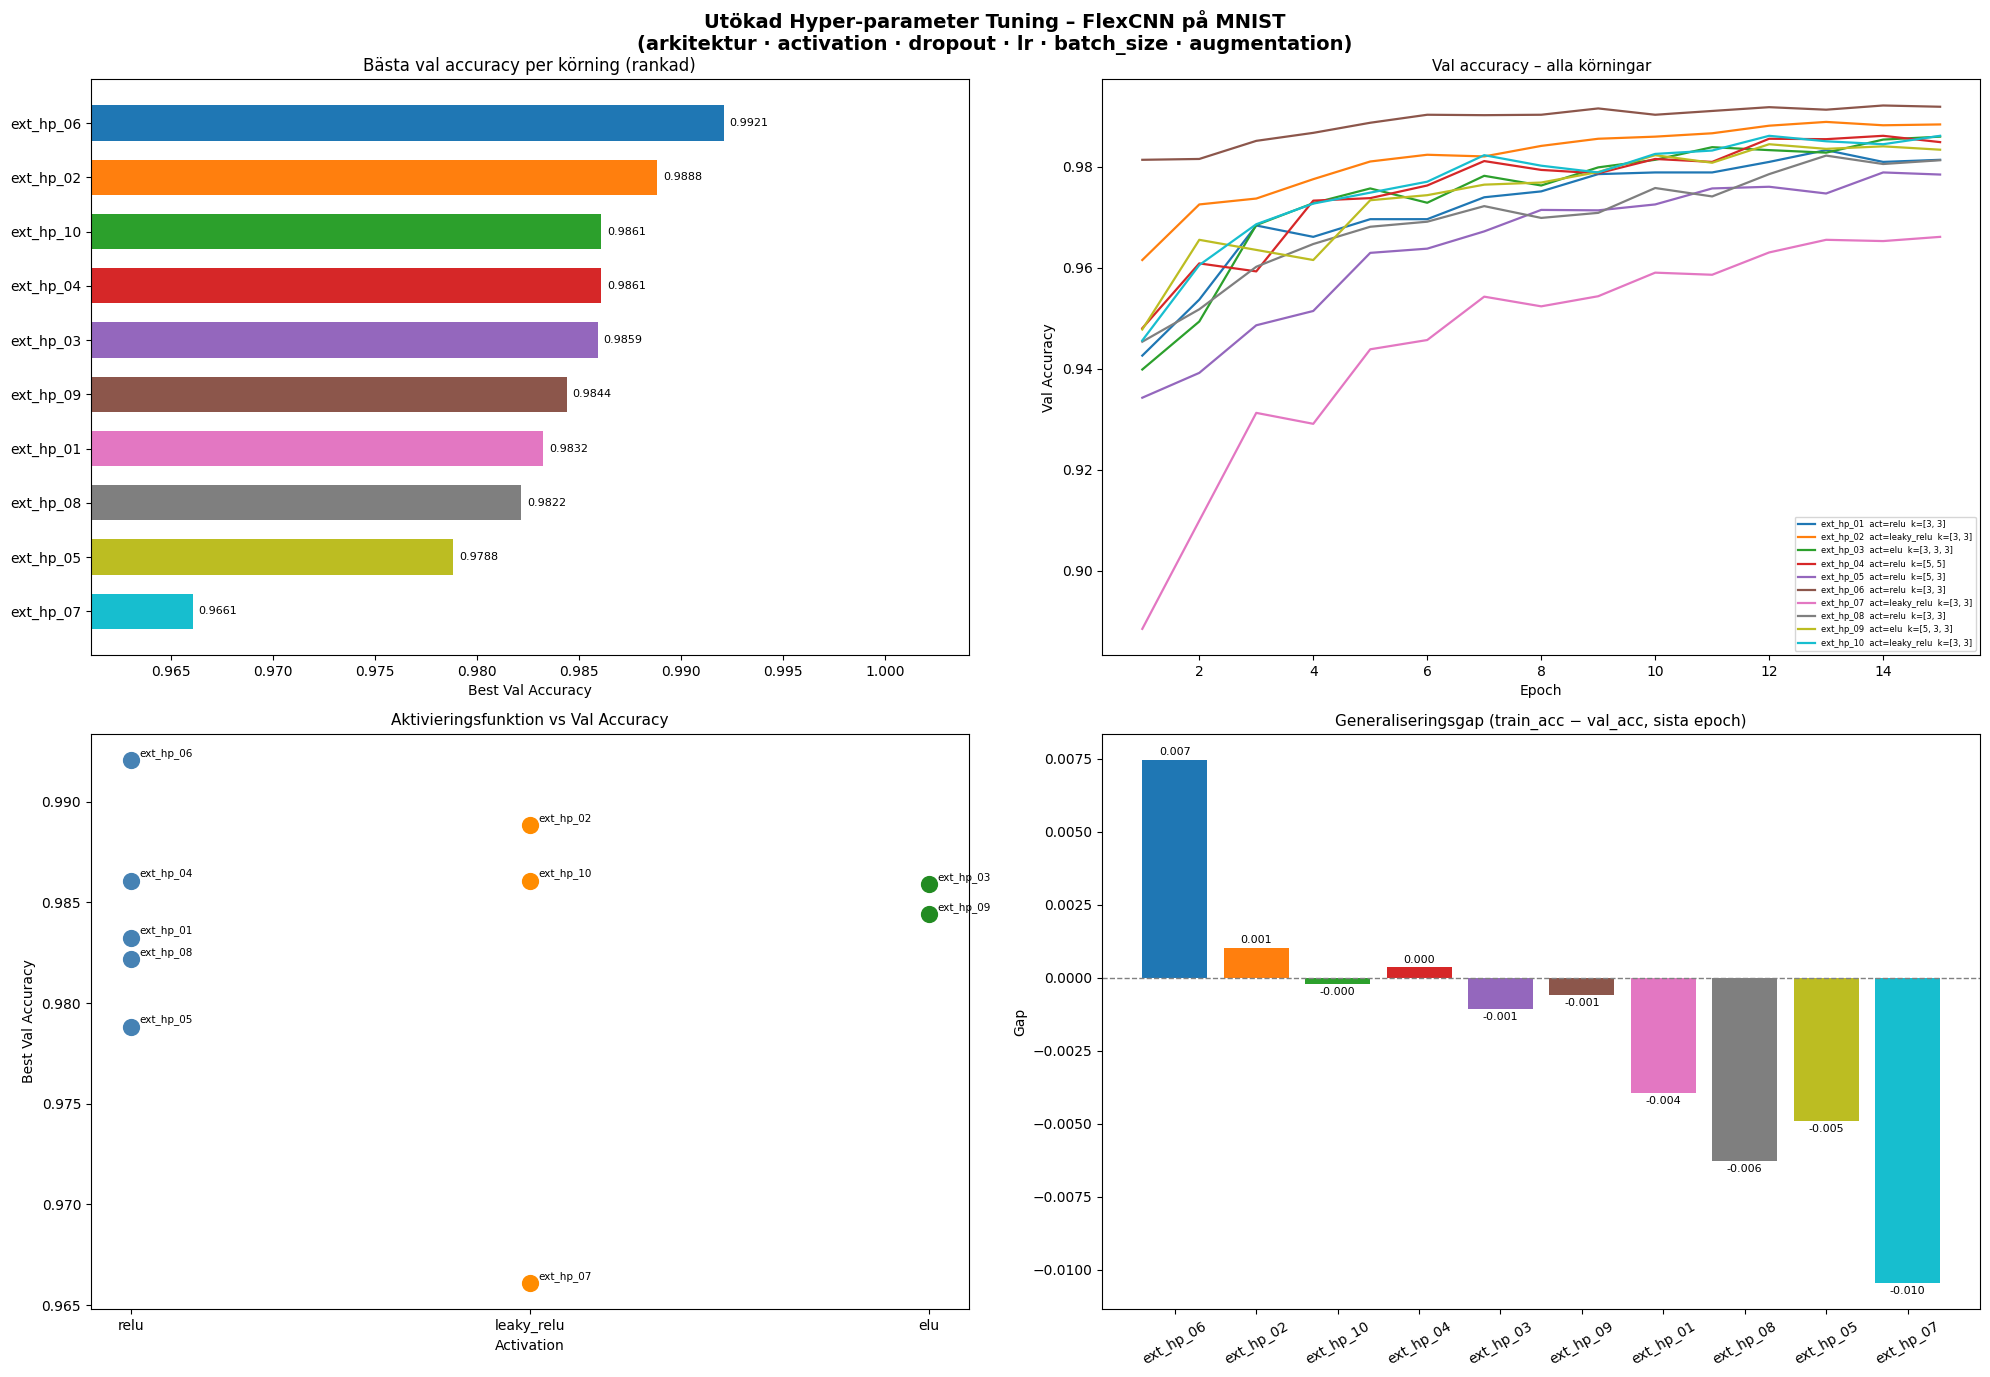

In [26]:

COLORS10 = plt.cm.tab10.colors
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Panel 1: Bästa val-accuracy – horisontellt stapeldiagram, rankad
ax = axes[0, 0]
bar_c = [COLORS10[i % 10] for i in range(len(ext_df))]
bars  = ax.barh(ext_df["run"][::-1], ext_df["best_val_acc"][::-1],
                color=bar_c[::-1], height=0.65)
ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=8)
lo = ext_df["best_val_acc"].min()
ax.set_xlim(lo - 0.005, ext_df["best_val_acc"].max() + 0.012)
ax.set_title("Bästa val accuracy per körning (rankad)", fontsize=12)
ax.set_xlabel("Best Val Accuracy")

# Panel 2: Val accuracy-kurvor per epoch
ax = axes[0, 1]
for i, r in enumerate(ext_results):
    h = ext_histories[r["run"]]
    c = r["config"]
    lbl = f"{r['run']}  act={c['activation']}  k={c['kernel_sizes']}"
    ax.plot(range(1, len(h["val_acc"]) + 1), h["val_acc"],
            color=COLORS10[i % 10], linewidth=1.6, label=lbl)
ax.set_title("Val accuracy – alla körningar", fontsize=11)
ax.set_xlabel("Epoch"); ax.set_ylabel("Val Accuracy")
ax.legend(fontsize=6, loc="lower right")

# Panel 3: Aktivieringsfunktion vs bästa val accuracy
ax = axes[1, 0]
act_palette = {"relu": "steelblue", "leaky_relu": "darkorange", "elu": "forestgreen"}
for _, row in ext_df.iterrows():
    ax.scatter(row["activation"], row["best_val_acc"], s=130,
               color=act_palette[row["activation"]], zorder=3)
    ax.annotate(row["run"], (row["activation"], row["best_val_acc"]),
                textcoords="offset points", xytext=(6, 3), fontsize=7.5)
ax.set_title("Aktivieringsfunktion vs Val Accuracy", fontsize=11)
ax.set_xlabel("Activation"); ax.set_ylabel("Best Val Accuracy")

# Panel 4: Generaliseringsgap
ax = axes[1, 1]
bar_c2 = [COLORS10[i % 10] for i in range(len(ext_df))]
bars2  = ax.bar(ext_df["run"], ext_df["generalization_gap"], color=bar_c2)
ax.bar_label(bars2, fmt="%.3f", padding=2, fontsize=8)
ax.set_title("Generaliseringsgap (train_acc − val_acc, sista epoch)", fontsize=11)
ax.set_ylabel("Gap"); ax.tick_params(axis="x", rotation=30)
ax.axhline(0, linestyle="--", linewidth=1, color="gray")

plt.suptitle(
    "Utökad Hyper-parameter Tuning – FlexCNN på MNIST\n"
    "(arkitektur · activation · dropout · lr · batch_size · augmentation)",
    fontsize=14, fontweight="bold",
)
plt.tight_layout()
plt.show()


## Slutkontroll innan inlämning

Kör cellen nedan efter alla träningsceller. Den sammanfattar de viktigaste resultaten som du kan använda som underlag när du själv skriver din reflektion.


In [27]:
# Slutkontroll: samla de viktigaste resultaten från Part 2
print("=== Part 2 sanity check ===")

if "summary_df" in globals():
    display(summary_df)
    best = summary_df.iloc[0]
    print(f"Bästa arkitektur: {best['run']}")
    print(f"Best val acc: {best['best_val_acc']:.4f}")
    print(f"Best val loss: {best['best_val_loss']:.4f}")
    print(f"Generalization gap: {best['generalization_gap']:.4f}")

if "test_acc" in globals():
    print(f"Test accuracy för bästa sparade modell: {test_acc:.4f}")

if "ext_df" in globals():
    print("\nBästa utökade hyperparameter-körning:")
    display(ext_df.head(3))


=== Part 2 sanity check ===


,run,best_val_loss,epoch_best_val_loss,best_val_acc,epoch_best_val_acc,final_train_acc,final_val_acc,final_train_loss,final_val_loss,generalization_gap,epochs,batch_size,lr,weight_decay,dropout,ckpt_every,dataset,architecture
2,LargeCNN,0.031559,19,0.990000,19,0.989021,0.989917,0.034422,0.031941,-0.000896,20,64,0.001,0.0001,0.4,5,MNIST,LargeCNN
1,MediumCNN,0.043203,18,0.986500,18,0.983104,0.984667,0.055040,0.044590,-0.001563,20,64,0.001,0.0001,0.3,5,MNIST,MediumCNN
0,SmallCNN,0.102062,19,0.967083,20,0.948354,0.967083,0.166725,0.104507,-0.018729,20,64,0.001,0.0001,0.3,5,MNIST,SmallCNN


Bästa arkitektur: LargeCNN
Best val acc: 0.9900
Best val loss: 0.0316
Generalization gap: -0.0009

Bästa utökade hyperparameter-körning:


,run,conv_channels,kernel_sizes,fc_hidden,activation,dropout,lr,batch_size,aug_rot,aug_erase_p,best_val_acc,generalization_gap
0,ext_hp_06,"[32, 64]","[3, 3]",[256],relu,0.30,0.0010,64,0,0.00,0.992083,0.007458
1,ext_hp_02,"[16, 32]","[3, 3]",[128],leaky_relu,0.20,0.0010,64,10,0.10,0.988833,0.001021
2,ext_hp_10,"[32, 64]","[3, 3]","[512, 128]",leaky_relu,0.15,0.0003,128,10,0.15,0.986083,-0.000229
